จำนวนภาพต่อคลาสในชุด train หลัง balance
----------------------------------------------------------------
  199 ว   ภาพจริง 1,310  +  augment 2,509  =  3,819 ภาพ
  171 ซ   ภาพจริง   224  +  augment 3,595  =  3,819 ภาพ
  170 ช   ภาพจริง   770  +  augment 3,049  =  3,819 ภาพ
----------------------------------------------------------------
ทุกคลาสถูกเติมจนเท่ากันที่ 3,819 ภาพ (= จำนวนของคลาสที่มีภาพมากสุด)
ชนิด augment ที่ใช้กับสามคลาสนี้: ['intense', 'original']

จำนวนสำเนา augment ต่อภาพจริงหนึ่งใบ
----------------------------------------------------------------
  199 ว   2,509 / 1,310  =  ใช้ต้นฉบับซ้ำเฉลี่ย 1.9 ครั้ง
  171 ซ   3,595 /   224  =  ใช้ต้นฉบับซ้ำเฉลี่ย 16.0 ครั้ง
  170 ช   3,049 /   770  =  ใช้ต้นฉบับซ้ำเฉลี่ย 4.0 ครั้ง
----------------------------------------------------------------
คลาสที่มีภาพจริงน้อยถูกใช้เป็นต้นแบบซ้ำมากกว่า ซึ่งเป็นกลไกของการ balance โดยตรง
(manifest แจกงานแบบ round-robin ทุกภาพจริงจึงถูกใช้เป็นต้นแบบใกล้เคียงกัน)
ผลคือในกราฟถัดไป ว จะมีช่อง augment ว

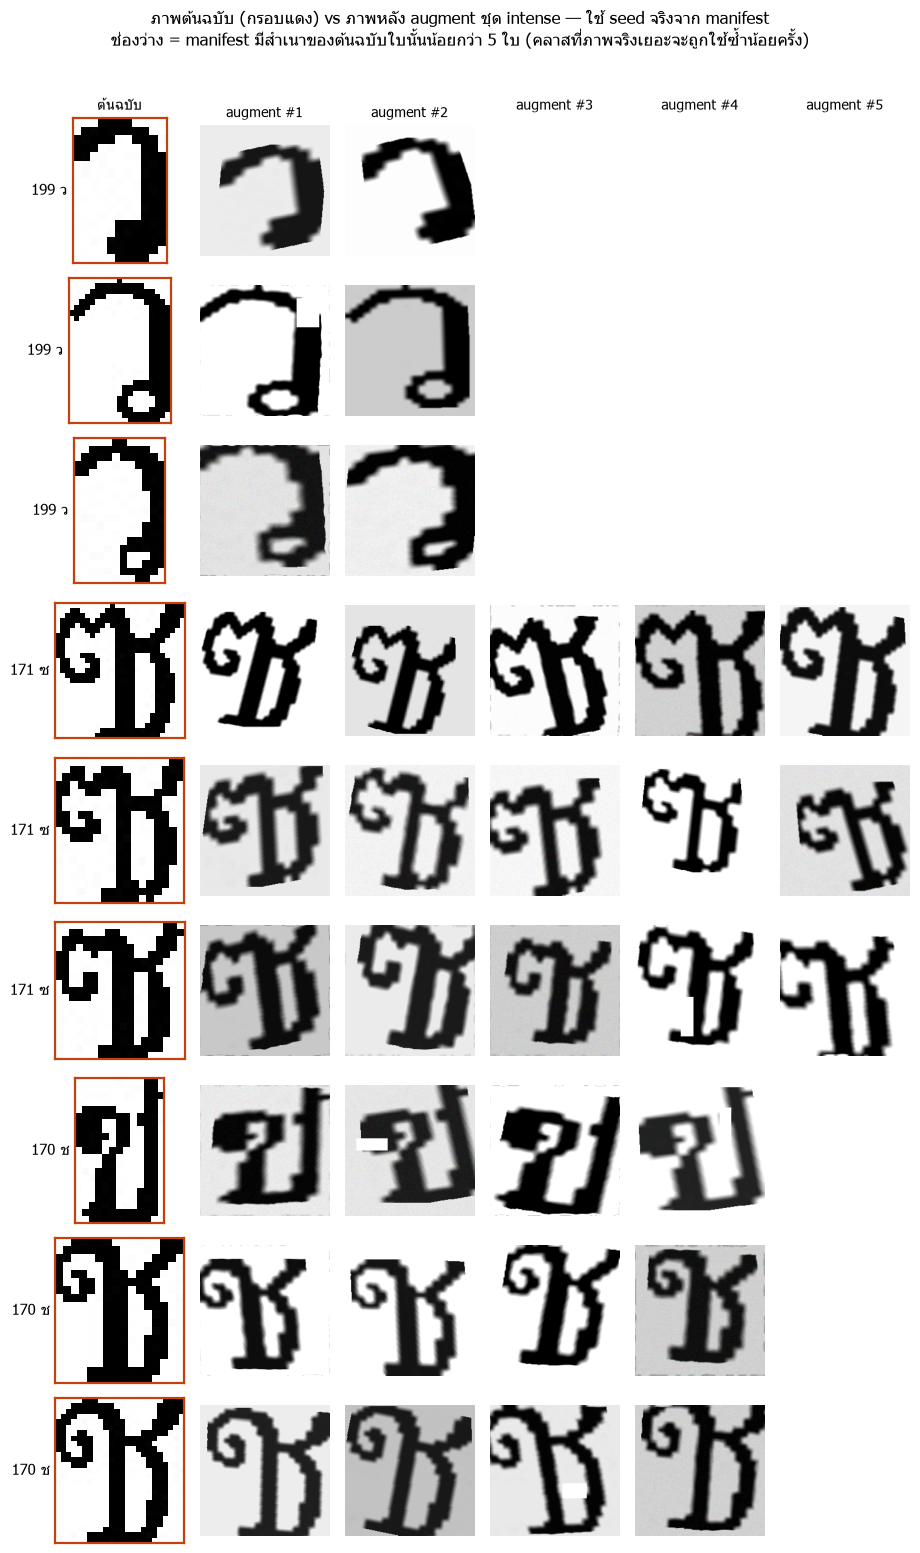

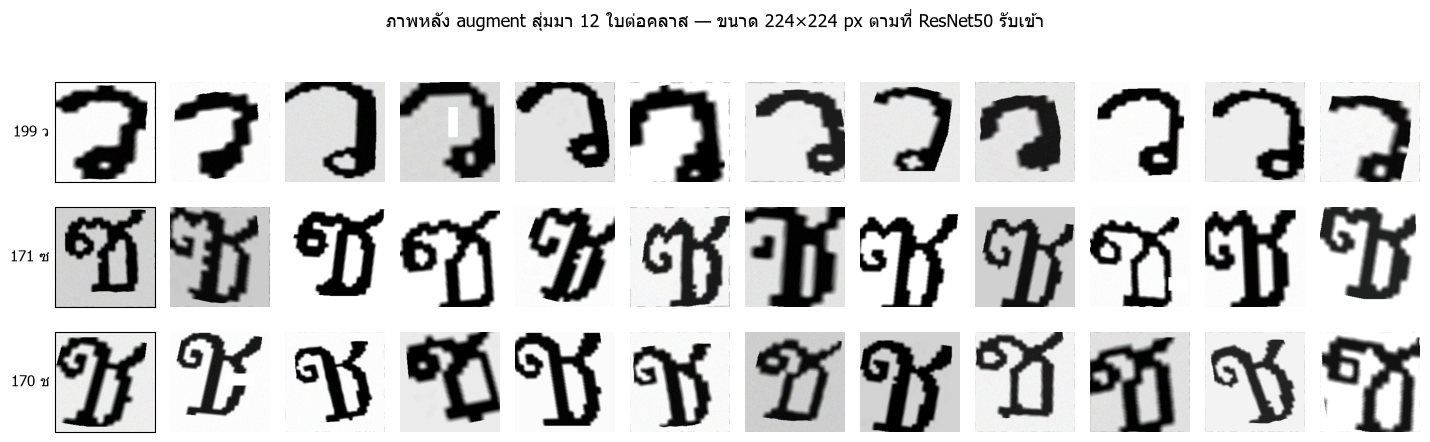

สังเกต: ว ซ ช ต่างกันที่รายละเอียดเล็ก ๆ (ห่วงล่าง เส้นหยัก หัวโค้ง) ซึ่งเป็นเหตุผล
ที่ทั้งสามคลาสถูกคัดเป็นคลาสที่ทายผิดบ่อย — augment ชุด intense จึงตั้งใจกวนภาพให้
โมเดลเห็นความแปรผันของรายละเอียดพวกนี้มากขึ้น โดยไม่บิดจนเปลี่ยนเป็นตัวอักษรอื่น


In [1]:
# ============================================================================
# ภาพคลาส ว / ซ / ช ที่ผ่าน Error-driven Balanced Augmentation ของ version2
# ============================================================================
# ทั้งสามคลาสอยู่ในลิสต์ "คลาสที่ทายผิดบ่อย" ที่คัดมาจาก baseline (ขั้นที่ 2)
# จึงถูก augment ด้วย transform ชุด intense:
#   RandomRotation ±15° · RandomAffine (translate 8%, scale 0.80–1.05, shear 8°)
#   ElasticTransform (p=0.50) · morphological dilate/erode (p=0.45)
#   GaussianBlur (p=0.30) · ColorJitter 0.20 · Gaussian noise (p=0.50)
#   RandomErasing (p=0.15) · ไม่มี flip เพราะตัวอักษรไทยมีทิศทาง
#
# ภาพในเซลล์นี้ใช้ "seed จริงจาก manifest" ที่ใช้ตอนเทรน จึงเป็นภาพเดียวกับที่
# โมเดลเห็นจริง ไม่ใช่การสุ่มใหม่ และเซลล์นี้อ่านไฟล์เท่านั้น ไม่เขียนอะไรลงดิสก์
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

# ต้องรันจากในโฟลเดอร์ version2/ (หรือวาง notebook ไว้ที่นั่น) เพราะใช้โค้ดของ version2
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "torch_pipeline").exists() and (PROJECT_ROOT / "version2" / "torch_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT / "version2"
sys.path.insert(0, str(PROJECT_ROOT))

from torch_pipeline import augment as A
from torch_pipeline import config as cfg
from torch_pipeline import data as D

CLASSES = {"199": "ว", "171": "ซ", "170": "ช"}   # รหัสคลาส -> ตัวอักษร
N_SOURCES = 3        # จำนวนภาพต้นฉบับต่อคลาสในกราฟเปรียบเทียบ
N_VARIANTS = 5       # จำนวนภาพ augment ต่อหนึ่งต้นฉบับ
N_RANDOM = 12        # จำนวนภาพ augment แบบสุ่มต่อคลาสในกราฟที่สอง

# ฟอนต์ที่มี glyph ภาษาไทย ไม่งั้นป้ายกำกับจะเป็นกล่องสี่เหลี่ยม
from matplotlib import font_manager

_avail = {f.name for f in font_manager.fontManager.ttflist}
for _c in ("Tahoma", "Leelawadee UI", "Noto Sans Thai", "Sarabun", "Thonburi"):
    if _c in _avail:
        plt.rcParams["font.family"] = _c
        break

# ---------------------------------------------------------------------------
# อ่าน manifest ของ augmentation (หนึ่งแถว = หนึ่งภาพที่โมเดลเห็นต่อ epoch)
# ---------------------------------------------------------------------------
manifest_path = PROJECT_ROOT / "outputs" / "splits" / "train_manifest.csv.gz"
if not manifest_path.exists():
    raise FileNotFoundError(
        f"ไม่พบ {manifest_path}\n"
        "ไฟล์นี้ถูก gitignore ไว้ (สร้างใหม่ได้จาก run_step3_augment_plan.py ซึ่ง"
        " ล็อกด้วย SEED=42 จึงได้ manifest ชุดเดิมเสมอ)"
    )
manifest = pd.read_csv(manifest_path, dtype={"class_id": str}, compression="gzip")
sub = manifest[manifest["class_id"].isin(CLASSES)]

print("จำนวนภาพต่อคลาสในชุด train หลัง balance")
print("-" * 64)
table = sub.pivot_table(index="class_id", columns="aug_kind", values="filepath", aggfunc="count").fillna(0).astype(int)
for cid, char in CLASSES.items():
    row = table.loc[cid]
    orig = int(row.get("original", 0))
    synth = int(row.sum() - orig)
    print(f"  {cid} {char}   ภาพจริง {orig:>5,}  +  augment {synth:>5,}  =  {orig + synth:>5,} ภาพ")
print("-" * 64)
print(f"ทุกคลาสถูกเติมจนเท่ากันที่ {int(table.sum(axis=1).max()):,} ภาพ (= จำนวนของคลาสที่มีภาพมากสุด)")
print(f"ชนิด augment ที่ใช้กับสามคลาสนี้: {sorted(sub['aug_kind'].unique())}")

print()
print("จำนวนสำเนา augment ต่อภาพจริงหนึ่งใบ")
print("-" * 64)
for cid, char in CLASSES.items():
    row = table.loc[cid]
    orig = int(row.get("original", 0))
    synth = int(row.sum() - orig)
    print(f"  {cid} {char}   {synth:>5,} / {orig:>5,}  =  ใช้ต้นฉบับซ้ำเฉลี่ย {synth / orig:.1f} ครั้ง")
print("-" * 64)
print("คลาสที่มีภาพจริงน้อยถูกใช้เป็นต้นแบบซ้ำมากกว่า ซึ่งเป็นกลไกของการ balance โดยตรง")
print("(manifest แจกงานแบบ round-robin ทุกภาพจริงจึงถูกใช้เป็นต้นแบบใกล้เคียงกัน)")
print("ผลคือในกราฟถัดไป ว จะมีช่อง augment ว่างมากกว่า เพราะ manifest มีสำเนาของภาพ")
print("ต้นฉบับใบนั้นอยู่จริงแค่ ~2 ใบ ไม่ใช่ 5 ใบเหมือน ซ")

# ---------------------------------------------------------------------------
# กราฟ 1: ต้นฉบับ (คอลัมน์ซ้าย) vs ภาพ augment จริงจาก manifest
# ---------------------------------------------------------------------------
rows = []   # (class_id, char, filepath, [seed, ...])
for cid, char in CLASSES.items():
    aug_rows = sub[(sub["class_id"] == cid) & (sub["aug_kind"] == "intense")]
    # เลือกภาพต้นฉบับที่ถูกใช้เป็นต้นแบบบ่อยที่สุด เพื่อให้มี seed หลากหลายให้ดู
    by_file = aug_rows.groupby("filepath")["aug_seed"].apply(list)
    for filepath, seeds in by_file.sort_values(key=lambda s: s.str.len(), ascending=False).head(N_SOURCES).items():
        rows.append((cid, char, filepath, seeds[:N_VARIANTS]))

fig, axes = plt.subplots(len(rows), N_VARIANTS + 1, figsize=((N_VARIANTS + 1) * 1.55, len(rows) * 1.7))
for r, (cid, char, filepath, seeds) in enumerate(rows):
    axes[r, 0].imshow(D.load_rgb(filepath))
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    for s in axes[r, 0].spines.values():
        s.set_edgecolor("#C2410C"); s.set_linewidth(1.6)
    axes[r, 0].set_ylabel(f"{cid} {char}", fontsize=11, rotation=0, ha="right", va="center")
    if r == 0:
        axes[r, 0].set_title("ต้นฉบับ", fontsize=10)
    for c in range(1, N_VARIANTS + 1):
        ax = axes[r, c]
        ax.axis("off")
        if c - 1 < len(seeds):
            seed = int(seeds[c - 1])
            # augment_preview ใช้ transform + seed เดียวกับตอนเทรน แล้ว denormalize กลับมาให้ดูได้
            ax.imshow(A.augment_preview(filepath, "intense", seed=seed))
            ax.set_xlabel(f"seed {seed}", fontsize=6)
        if r == 0:
            ax.set_title(f"augment #{c}", fontsize=10)
fig.suptitle(
    "ภาพต้นฉบับ (กรอบแดง) vs ภาพหลัง augment ชุด intense — ใช้ seed จริงจาก manifest\n"
    "ช่องว่าง = manifest มีสำเนาของต้นฉบับใบนั้นน้อยกว่า 5 ใบ (คลาสที่ภาพจริงเยอะจะถูกใช้ซ้ำน้อยครั้ง)",
    y=1.012, fontsize=12,
)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# กราฟ 2: สุ่มภาพ augment ของแต่ละคลาสมาเรียงกัน เพื่อดูความหลากหลายภายในคลาส
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(len(CLASSES), N_RANDOM, figsize=(N_RANDOM * 1.2, len(CLASSES) * 1.5))
for r, (cid, char) in enumerate(CLASSES.items()):
    picks = sub[(sub["class_id"] == cid) & (sub["aug_kind"] == "intense")].sample(
        n=N_RANDOM, random_state=42
    )
    for c, (_, row) in enumerate(picks.iterrows()):
        axes[r, c].imshow(A.augment_preview(row["filepath"], "intense", seed=int(row["aug_seed"])))
        axes[r, c].axis("off")
    axes[r, 0].axis("on")
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(f"{cid} {char}", fontsize=11, rotation=0, ha="right", va="center")
fig.suptitle(
    f"ภาพหลัง augment สุ่มมา {N_RANDOM} ใบต่อคลาส — ขนาด {cfg.IMG_SIZE}×{cfg.IMG_SIZE} px "
    "ตามที่ ResNet50 รับเข้า",
    y=1.01, fontsize=13,
)
plt.tight_layout()
plt.show()

print("สังเกต: ว ซ ช ต่างกันที่รายละเอียดเล็ก ๆ (ห่วงล่าง เส้นหยัก หัวโค้ง) ซึ่งเป็นเหตุผล")
print("ที่ทั้งสามคลาสถูกคัดเป็นคลาสที่ทายผิดบ่อย — augment ชุด intense จึงตั้งใจกวนภาพให้")
print("โมเดลเห็นความแปรผันของรายละเอียดพวกนี้มากขึ้น โดยไม่บิดจนเปลี่ยนเป็นตัวอักษรอื่น")